In [1]:
import numpy as np
import matplotlib.pyplot as plt

# INTERPOLATE

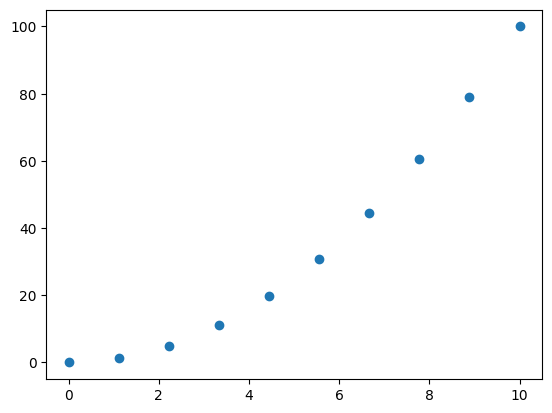

In [2]:
x = np.linspace(0,10,10)
y = x**2

plt.scatter(x,y)

on veux interploe ce graphe, c'est a dire completer les parties manquantes

In [4]:
from scipy.interpolate import interp1d

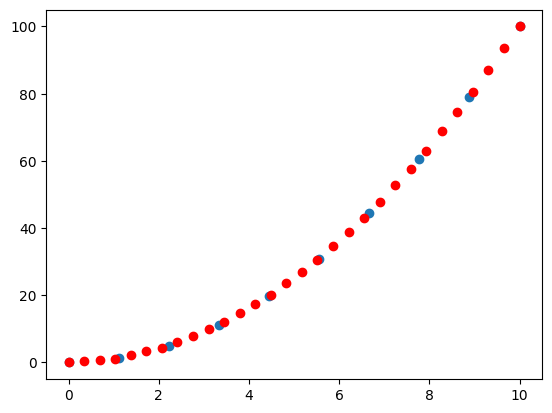

In [5]:
f = interp1d(x,y, kind="linear")
new_x = np.linspace(0,10,30)
resultat = f(new_x)

plt.scatter(x,y)
plt.scatter(new_x, resultat, c='r')

interpolation reuissi.

il existe plusieurs types( kind ) d'interpolation .
kind = 
    - linear
    - cubic

nb: le type d'interpolation depend graphe que l'on observe.


Exemple.

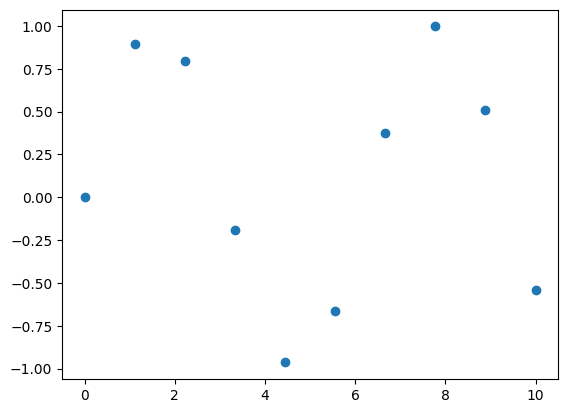

In [5]:
x = np.linspace(0,10,10)
y =np.sin(x)

plt.scatter(x,y)

pour ce genre de graphe utiliser, il un kind='cubic'

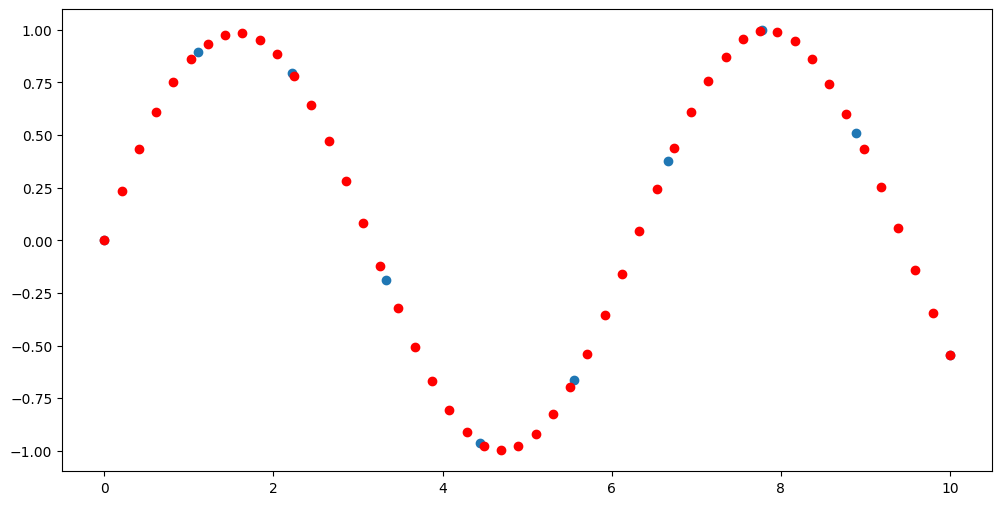

In [6]:
f = interp1d(x,y, kind="cubic")
new_x = np.linspace(0,10,50)
resultat = f(new_x)

plt.figure(figsize=(12,6))
plt.scatter(x,y)
plt.scatter(new_x, resultat, c='r')
plt.show()

nb: faire des recherches pour savoir c'est quoi une interpolatiomn : linear, cubic etc.

# MODULE  OPTIMISE

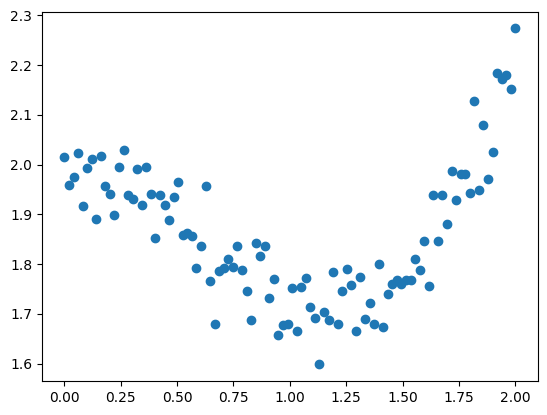

In [7]:
x = np.linspace(0,2,100)
y = 1/3*x**3 - 3/5*x**2 + 2+ np.random.randn(x.shape[0])/20

plt.scatter(x,y)

utilisation de ma fonction curve_fit pour que notre model rentre bien dans notre nuage de points.

Avant d'utiliser curve_fit:
    - il s'assuere de disposer d'un model.

### fonction curve_fit

In [8]:
def f(x,a,b,c,d):
    return a*x**3 + b*x**2 + c*x + d

In [9]:
from scipy import optimize

In [10]:
params , param_cov = optimize.curve_fit(f,x,y)

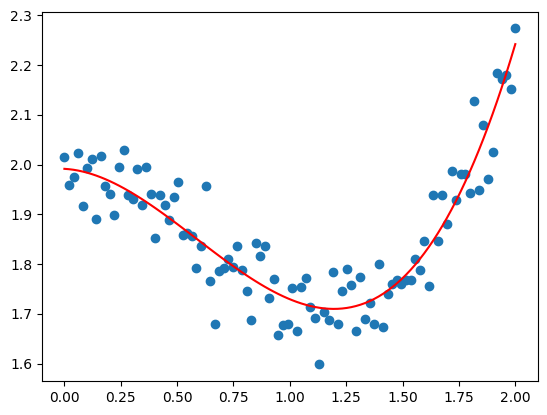

In [11]:
plt.scatter(x,y)
plt.plot(x, f(x,params[0],params[1],params[2],params[3]) ,c="r")

pour faire de la minimisation de fonction on utilise la fonction minimize.
la fonction minimize excecue un algorithme de minimisation afin de determiner le premier minimum.

### fonction minimize

In [12]:
def f(x):
    return x**2 + 15*np.sin(x)

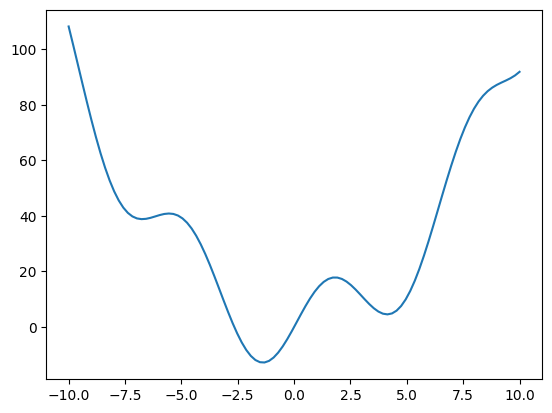

In [13]:
x = np.linspace(-10,10,100)
plt.plot(x, f(x))

In [14]:
# detection d'un minimum
optimize.minimize(f, x0= -5)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -12.823616887804414
        x: [-1.385e+00]
      nit: 4
      jac: [ 3.695e-06]
 hess_inv: [[ 5.979e-02]]
     nfev: 18
     njev: 9

In [15]:
# enregistrement de la valeur de x
result = optimize.minimize(f, x0 = -5).x
x0 = -5

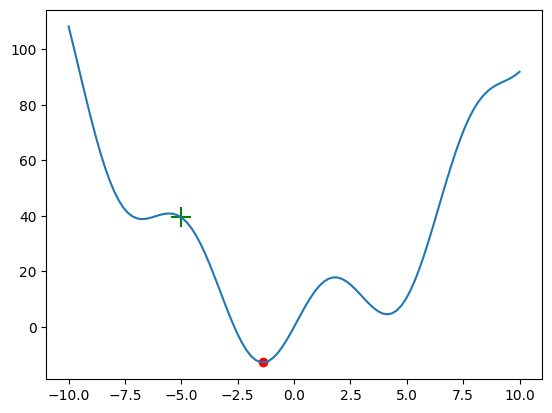

In [16]:
plt.plot(x, f(x))
plt.scatter(x0, f(x0),s=200 ,c="green" ,marker="+", zorder=1  )
plt.scatter(result, f(result), c="red", zorder=1  )

outre exemple d'application de la fonction minimize .
determinons le minimum de cette fonction.

In [17]:
def f(x):
    return np.sin(x[0]) + np.cos(x[0] + x[1]) * np.cos(x[0])

[-0.78539916 -2.35619344]


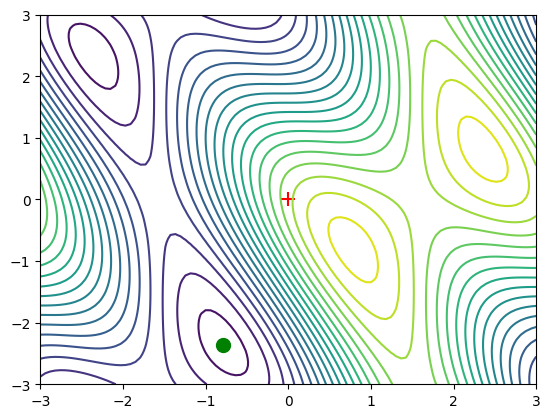

In [18]:
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)

X, Y = np.meshgrid(x,y)

plt.contour(X, Y, f(np.array([X,Y])),20)

# deterninons et affichons le minimum avec la couleur verte

x0 = np.zeros((2,1))
plt.scatter(x0[0], x0[1], marker="+", c="r", s=100)

    # x0 n'accepte que les valeurs de une dimension
result = optimize.minimize(f, x0=x0.ravel()).x

plt.scatter(result[0], result[1], s= 100, c="g")
print(result)


# TRAITEMENT DU SIGNAL

soit un sigmal

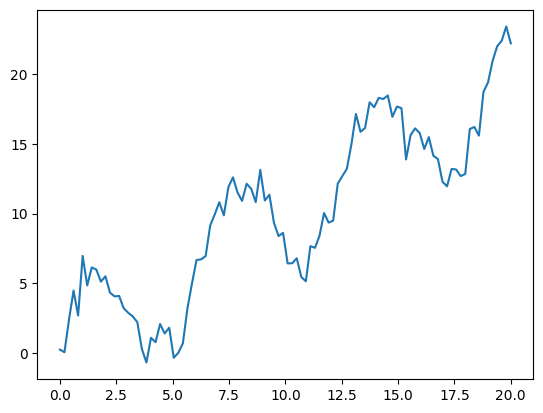

In [19]:
x = np.linspace(0, 20, 100)
y = x + 4*np.sin(x) + np.random.randn(x.shape[0])

plt.plot(x,y)


eliminer une tendence lineaire dans un signal

In [20]:
from scipy import signal

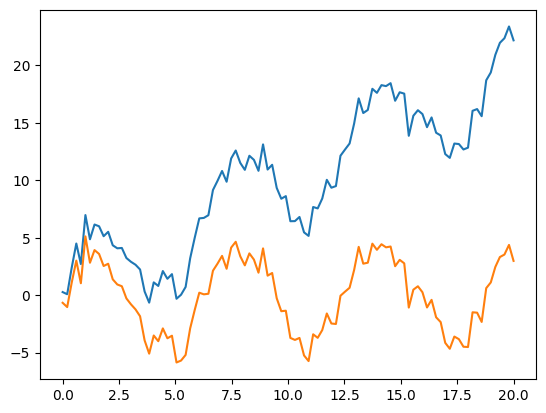

In [21]:
new_y = signal.detrend(y)

plt.plot(x,y)
plt.plot(x,new_y)

la transformation de fourier est une technique mathematique qui permet d'analyseer et d'
extraire les frequences qui sont presentent dans un signal periodique

signal

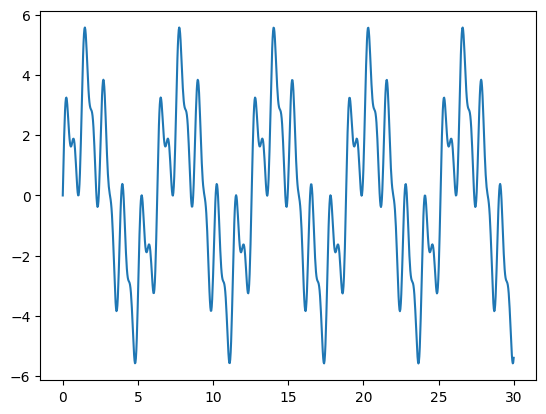

In [22]:
x = np.linspace(0, 30, 1000)
y = 3*np.sin(x) + 2*np.sin(5*x) + np.sin(10*x)
plt.plot(x, y)

In [23]:
from scipy import fftpack

c:\Users\Mr_B\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Mr_B\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


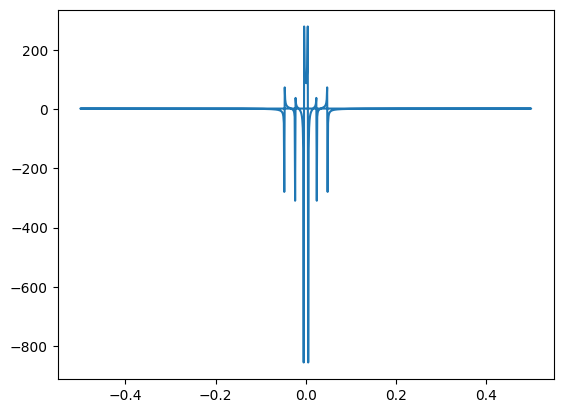

In [24]:
amplitude = fftpack.fft(y)
frequence = fftpack.fftfreq(y.size)
plt.plot(frequence, amplitude)

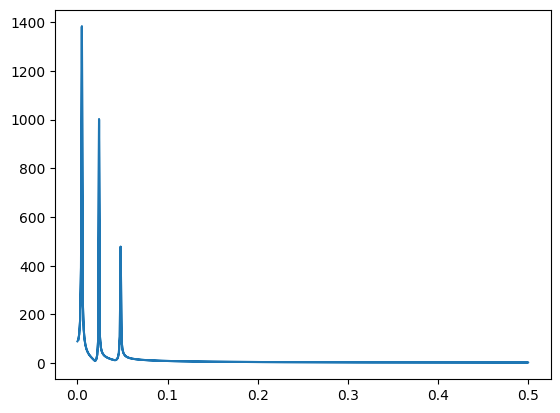

In [25]:
# nous allons mettre les valeurs de la  frenquence ainsi que cette de la variable amplitude en 
# valeur  absolue . 

plt.plot(np.abs(frequence), np.abs(amplitude))

autre exemple: comment filtrer un signal 

    1- appliquer la transformer de fourier pour abtenir un spectre
    2-  utiliser le boolean indexing afin d'eleminer toutes les valeurs qui sont 
        inferieur a un certaines valeur dans notre spectre

    3- aplliquer la transformer de fourier inverse a notre spectre afin de retrouver un signal totalement propre.

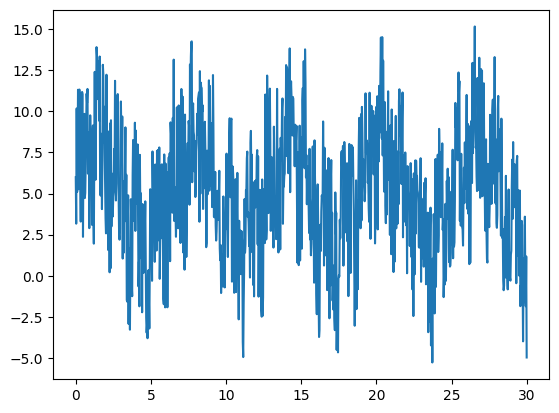

In [26]:
x = np.linspace(0, 30, 1000)
y = 3*np.sin(x) + 2*np.sin(5*x) + np.sin(10*x) + np.random.random(x.shape[0])*10
plt.plot(x, y)

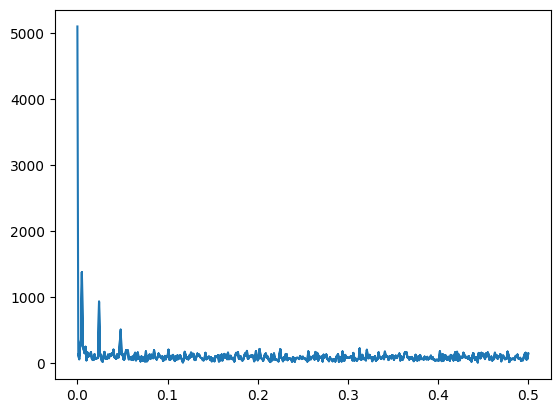

In [27]:
# 1- spectre 
fourier = fftpack.fft(y)
power = np.abs(fourier)
frequence = fftpack.fftfreq(y.size)
plt.plot(np.abs(frequence), power)


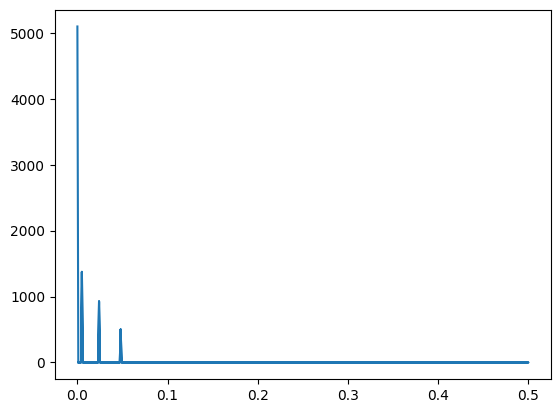

In [28]:
# 2- filtrage du spectre 

fourier[power < 400] = 0
plt.plot(np.abs(frequence), np.abs(fourier))

In [29]:
# transformer de fourier inverse

filtered_signal = fftpack.ifft(fourier)

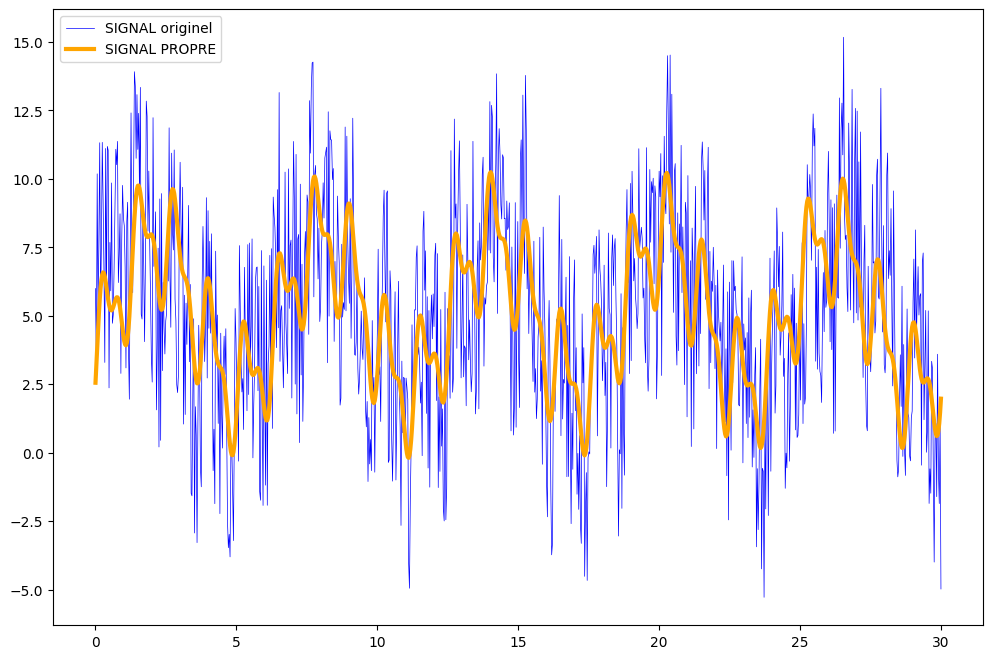

In [30]:
plt.figure(figsize=(12,8))
plt.plot(x,y , lw=0.5 , c="b", label='SIGNAL originel')
plt.plot(x, filtered_signal, lw=3 , c="orange", label='SIGNAL PROPRE')
plt.legend()
plt.show()

# image processing

In [31]:
from scipy import ndimage

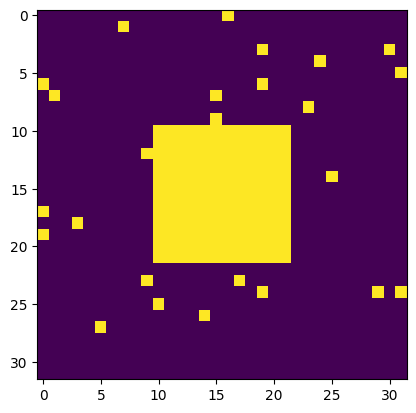

In [32]:
np.random.seed(0)
x = np.zeros((32,32))
x[10:-10, 10:-10] = 1
x[np.random.randint(0,32,30), np.random.randint(0,32,30)] = 1
plt.imshow(x)



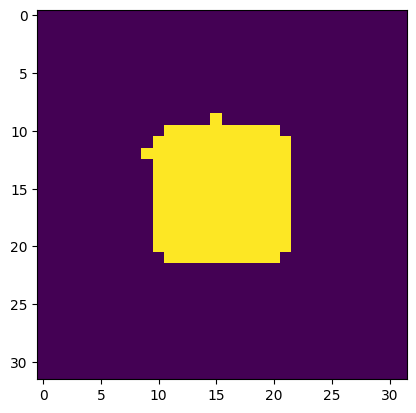

In [33]:
open_x = ndimage.binary_opening(x)
plt.imshow(open_x)

# binary_opening fait a la fois de la dilatation et de l'erosion

exemples :

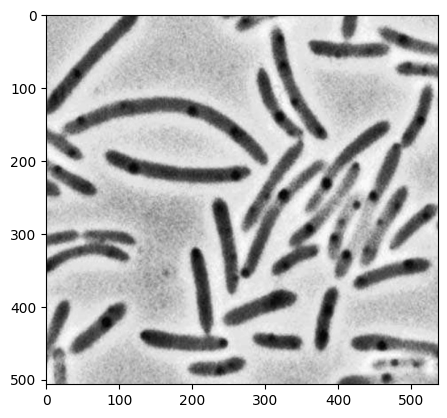

In [41]:
# importation de l'image
image = plt.imread("bacteria.png")
    # mettons la en deux dimension 
image = image[:, :, 0]
plt.imshow(image, cmap="gray")

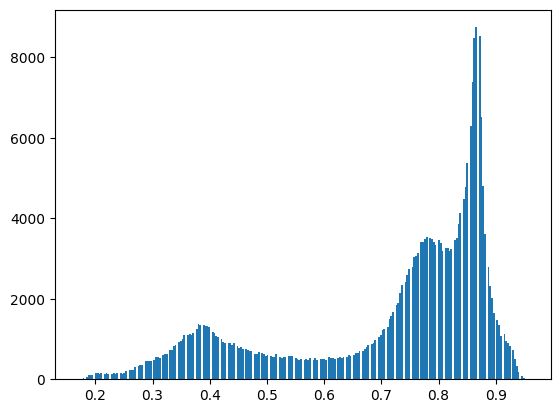

In [42]:
# affichons les pixels sont formes d'histogramme afin d'analyser la photo

image_2 = np.copy(image)
plt.hist(image_2.ravel(), bins=255)
plt.show()


on observe clairement qu'il y a trois grande partie 
    de 0 a 0,6 la partie sombre
    de 0,6 a 0,8 la partie grise
    de 0.8 -> la partie blanche 

puisqu'on cherhce a conserver que la bacteries qui osnt de couleur noir an va donc supprimer tous le reste

In [43]:
image = image < 0.6
image

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

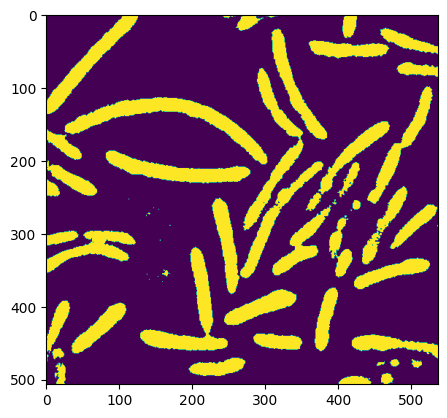

In [44]:
# ce servant de cet masque on aura une image en binaire

plt.imshow(image)

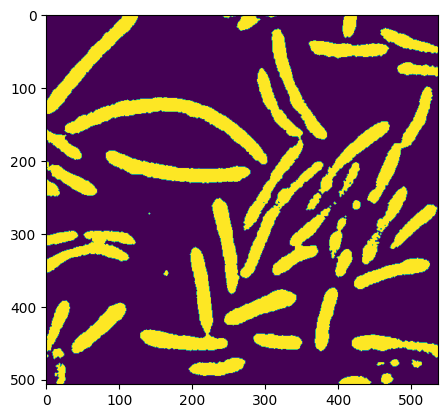

In [45]:
# reduction des artefactes 
open_x = ndimage.binary_opening(image)
plt.imshow(open_x)

In [46]:
# label_image represente nos bacteries etiquete
# n_label represente le nombre d'etiquette

label_image, n_label = ndimage.label(open_x)
print(n_label)

53


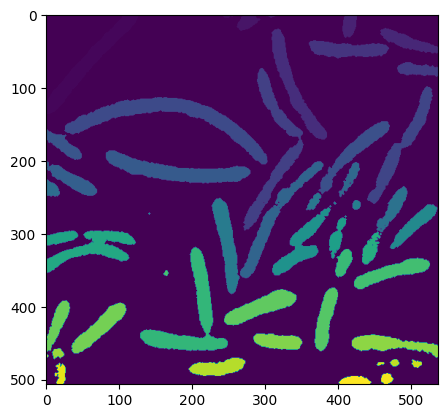

In [47]:

plt.imshow(label_image)

In [49]:
sizes = ndimage.sum(open_x, label_image, range(n_label))
sizes 

# la taille de chaque bacterie sur notre photo

array([0.000e+00, 3.321e+03, 7.500e+01, 4.620e+02, 5.800e+01, 5.220e+02,
       1.167e+03, 2.706e+03, 1.837e+03, 7.720e+02, 3.722e+03, 2.746e+03,
       5.733e+03, 2.060e+03, 8.600e+02, 3.820e+03, 1.222e+03, 2.733e+03,
       4.810e+02, 3.170e+02, 9.790e+02, 2.510e+02, 2.317e+03, 1.180e+02,
       1.000e+01, 1.218e+03, 5.000e+00, 2.176e+03, 5.000e+00, 5.000e+00,
       6.070e+02, 5.860e+02, 2.692e+03, 6.140e+02, 5.000e+00, 4.295e+03,
       5.880e+02, 1.849e+03, 3.600e+01, 1.498e+03, 2.183e+03, 1.006e+03,
       1.825e+03, 1.147e+03, 1.826e+03, 1.690e+02, 1.200e+01, 1.276e+03,
       9.400e+01, 1.070e+02, 3.700e+01, 3.010e+02, 1.900e+02])

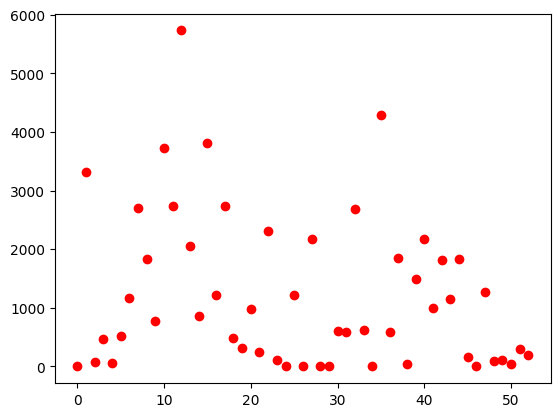

In [50]:
plt.scatter(range(n_label), sizes, c="r")